In [47]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math
p_print = lambda p : display(Math(p))

## Diferencias finitas: discretización de una derivada

La expansión de series de Taylor de una función:

\begin{equation}
f\left(x_{n+1}\right)=f\left(x_n\right)+\left(x_{n+1}-x_n\right) f^{\prime}\left(x_n\right)+\frac{\left(x_{n+1}-x_n\right)^2}{2} f^{\prime \prime}\left(x_n\right)+\ldots
\end{equation}

puede ser reordenada para obtener:

\begin{equation}
f^{\prime}\left(x_n\right)=\color{red}{\frac{f\left(x_{n+1}\right)-f\left(x_n\right)}{\Delta x_n}}-\color{blue}{\frac{\Delta x_n}{2} f^{\prime \prime}\left(x_n\right)+\ldots}
\end{equation}

con $\Delta x_n=x_{n+1}-x_n$, el paso de integración.

- Si $\Delta x_n=\text{cte}$, definiremos $h=\Delta x_n$.
- El término de la izquierda <span style="color:red">(en rojo)</span> corresponde a una <b>aproximación de diferencias finitas a la derivada de $f$</b>.
- El resto de los términos de la derecha <span style="color:blue">(en azul)</span> corresponden al <b>error de esta aproximación</b> $O(h)$

### Esquemas de diferenciación basados en la expansión de series de Taylor

<p style="text-align:justify">En base a la expansión de serie de Taylor, respecto a puntos específicos y considerando pasos de itnegración constantes $h$, podemos definir distintos esquemas de discretos de diferenciación, que nos permitirán estimar derivadas numéricamente.</p>

<ul style="text-align:justify">
    <li>
        <b> Diferencia progresiva </b>

\begin{equation}
    f_n^{\prime}=\frac{f_{n+1}-f_n}{h}+\mathcal{O}(h)
\end{equation}

Notar que $f_n^\prime$ se calcula a partir de la función evaluada en el punto $n$ y un punto "más" adelante $(n+1)$
    </li>
    <li>
        <b> Diferencia regresiva </b>
    
\begin{equation}
f_n^{\prime}=\frac{f_n-f_{n-1}}{h}+\mathcal{O}(h)
\end{equation}

En este caso, la el término diferencial se ahora considerando un punto anterior a $n$
    </li>
</ul>

Si combinamos los esquemas de diferencias progresivas y regresivas, podemos obtener:

<ul style="text-align:justify">
    <li>
        <b> Diferencia central </b>
        
\begin{equation}
    f_n^{\prime}=\frac{f_{n+1}-f_{n-1}}{2 h}+\mathcal{O}\left(h^2\right)
\end{equation}
        
<span style="text-align:justify">La cual, ahora, considera dos puntos adicionales a $x_n$: $x_{n-1}$ y $x_{n+1}$. Notar que el error asociado a este esquema es de orden $\mathcal{O}(h^2)$, por lo que decrecerá más rapido a medida que $h$ disminuye.</span>

<p style="text-align:justify">Otros esquemas de mayor orden pueden ser obtenidos al cominar la expansión de series de Taylor respecto a distintos puntos adicionales. De manera general: al combinar más puntos, es posible obtener esquemas de diferenciación de mayor orden (los cuales deberían estar asociados a un menor error).</p>

#### Ejemplo

Determinar mediante diferencia progresiva la derivada:

\begin{equation*}
\frac{d f}{d x}=\frac{d}{d x}[\sin (x)]
\end{equation*}

Para $-\pi<x<\pi$



Dividiremos nuestro intervalo en 100 intervalos de igual longitud

In [48]:
x = np.linspace(-np.pi,np.pi,10)

El tamaño del paso de integración $h$ es de:

In [49]:
h = x[1]-x[0]
p_print(fr'h \approx {h:.5f}')

<IPython.core.display.Math object>

Evaluaremos la función $f$ en cada punto perteneciente al intervalo:

In [50]:
f = np.sin(x)

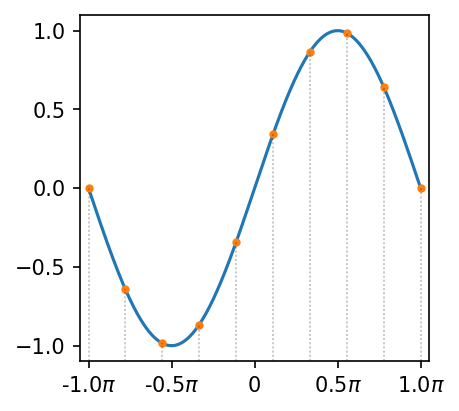

In [51]:
fig = plt.figure(figsize=(3,3),dpi=150)
ax  = fig.add_subplot(111)

xx = np.linspace(-np.pi,np.pi,1000)
ff = np.sin(xx)

ax.plot(xx,ff)
ax.plot(x,f,'.')

for i,v in enumerate(x):
    ax.plot([v,v],[-1.1,f[i]],'k--',linewidth=0.2,dashes=(5,5))
ax.set_ylim(-1.1,1.1)

ax.set_xticks(np.arange(-np.pi,np.pi+np.pi/4,np.pi/2))
numbs = np.arange(-1,1+1/2,1/2)
ax.set_xticklabels([fr'{x}$\pi$' if abs(x)>0 else '0' for x in numbs])
ax.set_xlim(-np.pi*1.05,np.pi*1.05) ;

Ahora, calculamos la diferencia progresiva:

$$\Delta f = f_{n+1} - f_{n}$$


In [52]:
Deltaf = np.diff(f)

y estimamos la derivada en cada punto:

$$ \frac{df}{dx} \approx \frac{\Delta f}{\Delta x} = \frac{f_{n+1}-f_n}{h}$$

In [53]:
df_dx = Deltaf/h

Comparación con la solución exacta:

$$\frac{df}{dx}=\frac{d}{dx}\sin(x) = \cos(x)$$

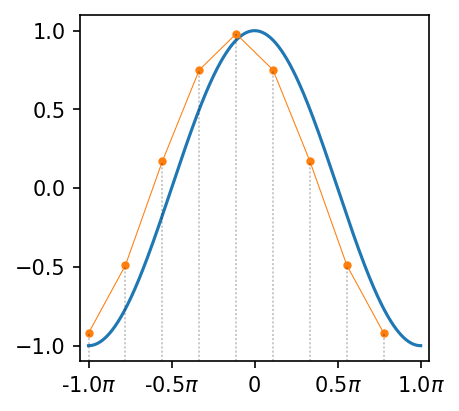

In [55]:
fig2 = plt.figure(figsize=(3,3),dpi=150)
ax2  = fig2.add_subplot(111)

xx2 = np.linspace(-np.pi,np.pi,1000)
ff2 = np.cos(xx2)

ax2.plot(xx2,ff2)
ax2.plot(x[:-1],df_dx,'C1-',linewidth=0.51)
ax2.plot(x[:-1],df_dx,'C1.')

for i,v in enumerate(x[:-1]):
    ax2.plot([v,v],[-1.1,df_dx[i]],'k--',linewidth=0.2,dashes=(5,5))
ax2.set_ylim(-1.1,1.1)

ax2.set_xticks(np.arange(-np.pi,np.pi+np.pi/4,np.pi/2))
numbs = np.arange(-1,1+1/2,1/2)
ax2.set_xticklabels([fr'{x}$\pi$' if abs(x)>0 else '0' for x in numbs])
ax2.set_xlim(-np.pi*1.05,np.pi*1.05);

Disminuyamos el tamaño del paso (aumentando el número de subintervalos)

In [33]:
def finit_diff(n_step):
    x2 = np.linspace(-np.pi,np.pi,n_step)
    h2 = x2[1]-x2[0]
    Deltaf2 = np.diff(np.sin(x2))
    df_dx2 = Deltaf2/h2
    return x2,df_dx2,h2

In [34]:
x2,df_dx2,h2 = finit_diff(20)
x3,df_dx3,h3 = finit_diff(40)

<>:4: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:4: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\yenny\AppData\Local\Temp\ipykernel_15312\35858279.py:4: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  ax3.plot(xx2,ff2,label='$\cos(x)$')


(-3.2986722862692828, 3.2986722862692828)

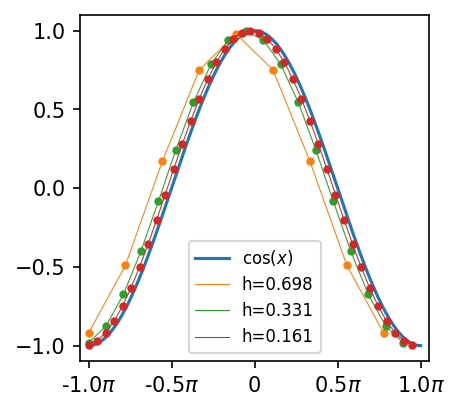

In [35]:
fig3 = plt.figure(figsize=(3,3),dpi=150)
ax3  = fig3.add_subplot(111)

ax3.plot(xx2,ff2,label='$\cos(x)$')
ax3.plot(x[:-1],df_dx,'C1-',linewidth=0.51,label=fr'h={h:.3f}')
ax3.plot(x[:-1],df_dx,'C1.')

ax3.plot(x2[:-1],df_dx2,'C2-',linewidth=0.51,label=fr'h={h2:.3f}')
ax3.plot(x2[:-1],df_dx2,'C2.')

ax3.plot(x3[:-1],df_dx3,'C3-',linewidth=0.51,label=fr'h={h3:.3f}')
ax3.plot(x3[:-1],df_dx3,'C3.')

ax3.legend(fontsize=8)
ax3.set_ylim(-1.1,1.1)

ax3.set_xticks(np.arange(-np.pi,np.pi+np.pi/4,np.pi/2))
numbs = np.arange(-1,1+1/2,1/2)
ax3.set_xticklabels([fr'{x}$\pi$' if abs(x)>0 else '0' for x in numbs])
ax3.set_xlim(-np.pi*1.05,np.pi*1.05)

##### Estimación del error

In [36]:
def error_df(x,df_dx):
    return np.average(np.abs(np.subtract(np.cos(x[:-1]),df_dx)))

In [37]:
Error1 = error_df(x,df_dx)
Error2 = error_df(x2,df_dx2)
Error3 = error_df(x3,df_dx3)
print(Error1,Error2,Error3)

0.21997950400566857 0.10502366424609655 0.05125432997084679


In [38]:
errors = []
hs     = []
for i in np.arange(10,1500,5):
    xn,dfn,hn = finit_diff(i)
    hs.append(hn)
    errors.append(error_df(xn,dfn))

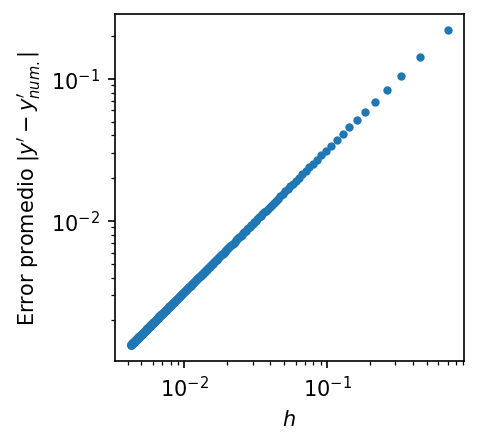

In [39]:
fig4 = plt.figure(figsize=(3,3),dpi=150)
ax4 = fig4.add_subplot(111)

ax4.plot(hs,errors,'.')
ax4.set_yscale('log')
ax4.set_xscale('log')

ax4.set_xlabel('$h$')
ax4.set_ylabel(r'Error promedio $|y^\prime-y^\prime_{num.}|$') ;

#### Problemas propuestos

##### Diferencias regresiva y central
Basandose en la libreria <span style="font-style:italic">numpy</span> y su función <span style="font-style:italic">diff</span>:

Repita el ejemplo anterior, utilizando:
- diferencia regresiva.
- diferencia central
Para cada uno de los casos propuestos, compare el error promedio obtenido con alque obtenido utilizando diferencia progresiva (para distintos pasos de integración).



##### Esquemas de mayor orden

Implemente la fórmula de cuarto orden, obtenida mediante la expansión de series de Taylor en los puntos $x_{n-2}$, $x_{n-1}$, $x_{n+1}$, $x_{n+2}$:

\begin{equation}
f_n^\prime= \frac{f_{n-2}-8f_{j-1}+8f_{j+1}-f_{j+2}}{12 h}
\end{equation}

Una vez implementado, compare los resultados obtenidos utilizando este esquema con aquellos obtenidos mediante diferencia progresiva.

Problema adicional: Obtenga analíticamente este esquema a partir de la expansión de series de Taylor en los puntos indicados anteriormente.

##### Aplicación

Estime mediante alguno de los esquemas anteriormente descritos las derivadas:

- $\displaystyle \frac{d}{dx} e^{-x}$

- $\displaystyle\frac{d}{dx} \left(\cos(x)+\sin(x)\right)$

- $\displaystyle\frac{d}{dx} \left(4x^5 + 3x^2 +2 \right)$

Compare sus resultados con la solución exacta y haga un análisis de error en función del tamaño del paso de integración.

#### Derivadas de mayor orden (con $\mathcal{O}(h^2)$)

Es posible determinar derivadas de mayor orden a partir de la expansión de series de Taylor en más de un punto. Por ejemplo, la segunda derivada puede estimarse a partir de la expansión en los puntos $x_{n-1}$ y $x_{n+1}$:

\begin{equation}
f_{n-1} = f_{n} - hf^\prime_{n} + \frac{h^2}{2}f^{\prime \prime}_{n}+ \frac{h^3}{6}f^{\prime\prime\prime}+\ldots
\end{equation}

\begin{equation}
f_{n+1} = f_{n} + hf^\prime_{n} + \frac{h^2}{2}f^{\prime \prime}_{n}-  \frac{h^3}{6}f^{\prime\prime\prime} +\ldots
\end{equation}


Al sumar \ref{eq:td_xmen1} y \ref{eq:td_xmas1} y reordenar obtendremos:

\begin{equation}
f_{n}^{\prime\prime} = \frac{f_{n+1}-2f_n+f_{n-1}}{h^2}+\mathcal{O}(h^2)
\end{equation}

Notar que esta expresión requiere evaluar también $f(x_n)$.

De forma similar podemos obtener expresiones para las derivadas de tercer y cuarto orden (y en general, de cualquier orden):

\begin{equation}
    f^{\prime \prime \prime}=\frac{f_{n+2}-2 f_{n+1}+2 f_{n-1}-f_{n-2}}{2 h^3}+\mathcal{O}\left(h^2\right)
\end{equation}

\begin{equation}
f^{(4)}=\frac{f_{n+2}-4 f_{n+1}+6 f_n-4 f_{n-1}+f_{n-2}}{h^4}+\mathcal{O}\left(h^2\right)
\end{equation}

## Diferencias finitas mediante <span style="font-style:italic">scipy</span>

El módulo scipy permite realizar derivadas numéricas mediante su función <span style="font-style:italic">derivative </span>
<a>https://docs.scipy.org/doc/scipy/reference/generated/scipy.differentiate.derivative.html </a>


In [40]:
from scipy.differentiate import derivative

### Ejemplo

Determinar la derivada:

$$\frac{d}{dx}sin(x)$$

en los puntos $x=1$ y $x=2$

In [41]:
funcd = lambda x: np.sin(x)
d_dx = derivative(f=funcd, # función
                  x=[1,2], # puntos
                 )
d_dx

     success: [ True  True]
      status: [0 0]
          df: [ 5.403e-01 -4.161e-01]
       error: [ 1.406e-12  1.087e-12]
         nit: [2 2]
        nfev: [11 11]
           x: [ 1.000e+00  2.000e+00]

La solución exacta es:

In [42]:
np.cos([1,2])

array([ 0.54030231, -0.41614684])

Error máximo: 0.05959999999999832


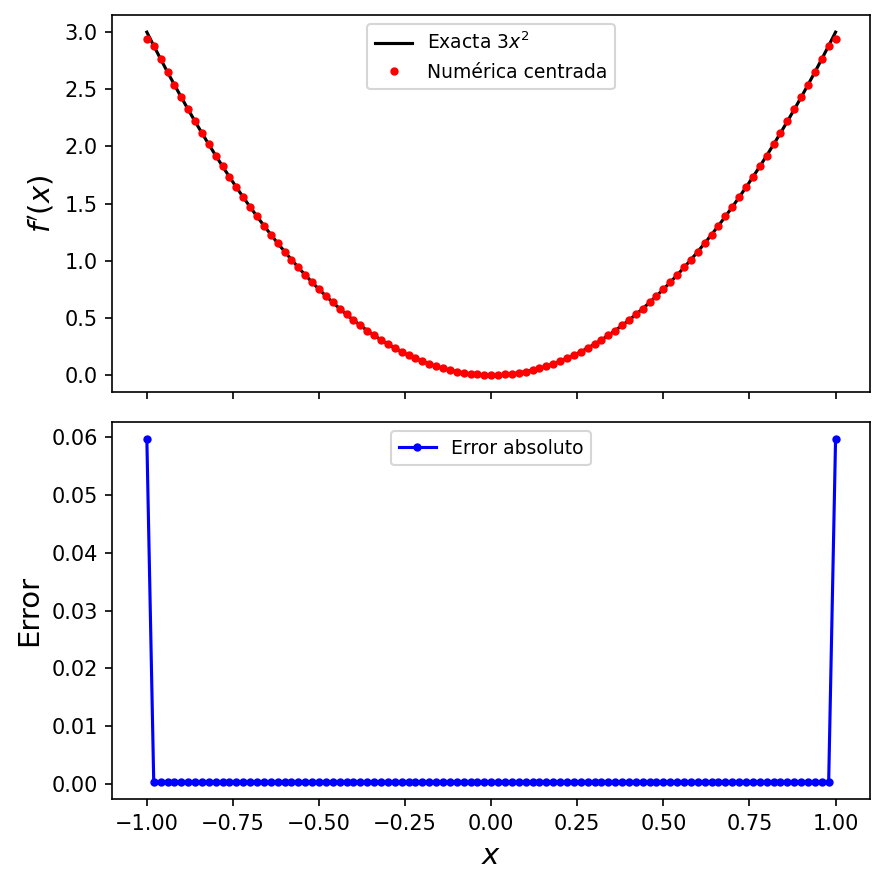

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Definir la función
def f(x):
    return x**3

def df_exact(x):
    return 3*x**2


# Malla de puntos y paso h
N = 101 #cantidad de puntos

x = np.linspace(-1.0, 1.0, N)
h = x[1] - x[0]

# Aproximar derivada con diferencia centrada
df_num = np.zeros_like(x)

# fórmula centrada en los puntos interiores:
# f'(x_i) ≈ [f(x_{i+1}) - f(x_{i-1})] / (2h)
df_num[1:-1] = (f(x[2:]) - f(x[:-2])) / (2*h)

# en los extremos usamos algo simple (forward/backward) solo para completar el vector
df_num[0]  = (f(x[1]) - f(x[0])) / h
df_num[-1] = (f(x[-1]) - f(x[-2])) / h

# 4) Derivada exacta y error
df_ex = df_exact(x)
error = np.abs(df_num - df_ex)

print("Error máximo:", error.max())

# 5) Gráficos: derivada y error
fig, axes = plt.subplots(2, 1, figsize=(6, 6), dpi=150, sharex=True)

ax1, ax2 = axes

# Derivada exacta vs numérica
ax1.plot(x, df_ex, 'k-',  label='Exacta $3x^2$')
ax1.plot(x, df_num, 'ro', label='Numérica centrada', markersize=3)
ax1.set_ylabel('$f\'(x)$', fontsize=14)
ax1.legend(loc='best', fontsize=9)
ax1.tick_params(axis='both', which='major', labelsize=10)

# Error
ax2.plot(x, error, 'b.-', label='Error absoluto')
ax2.set_xlabel('$x$', fontsize=14)
ax2.set_ylabel('Error', fontsize=14)
ax2.legend(loc='best', fontsize=9)
ax2.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()
plt.show()
